# Cinccinnati Paint Company

In [33]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 
%matplotlib inline 
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib import cm 
plt.rcParams['figure.figsize'] = (16, 9) 
plt.style.use('ggplot') 

# Importe de Datos
data = pd.read_csv("./CincinnatiPaintCompany.csv")
data.head()

,Commissions,Calls,Driven
0,22,139,2371
1,13,132,2226
2,33,144,2731
3,38,142,3351
4,23,142,2289


# 1. Determinar las variables independientes

In [34]:
X = data[["Driven", "Calls"]]
X 

,Driven,Calls
0,2371,139
1,2226,132
2,2731,144
3,3351,142
4,2289,142
5,3449,142
6,3114,138
7,3342,139
8,2842,144
9,2625,134


# #2. Determinar la variable dependiente

In [35]:
y = data[['Commissions']]
y

,Commissions
0,22
1,13
2,33
3,38
4,23
5,47
6,29
7,38
8,41
9,32


In [36]:
# Ajustar el modelo de regresión múltiple
model = LinearRegression()
model.fit(X, y) #Entrenando el modelo
y_pred = model.predict(X) #Predicciones del modelo
y_pred

#Métricas estadísticas
mse = mean_squared_error(y, y_pred) # Error de la media cuadrática
r2 = r2_score(y, y_pred) # Varianza

# 3. Valor de Intersección

In [37]:
model.intercept_

array([-101.31444968])

In [38]:
# Coeficientes de la regresión
print("Coeficientes: ", model.coef_)
print("Error de la media cuadrática (MSE): ", mse)
print("Varianza (R^2): ", r2)

Coeficientes:  [[0.01568925 0.63233256]]
Error de la media cuadrática (MSE):  16.313412727936058
Varianza (R^2):  0.8352686374291525


# 4. Estimación del Rendimiento del Trabajador

In [39]:
Y = model.predict(np.array([[2800, 143]]))
print("Rendimiento estimado del trabajador: ", Y)

Rendimiento estimado del trabajador:  [[33.03901808]]


c:\Users\angel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


c:\Users\angel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


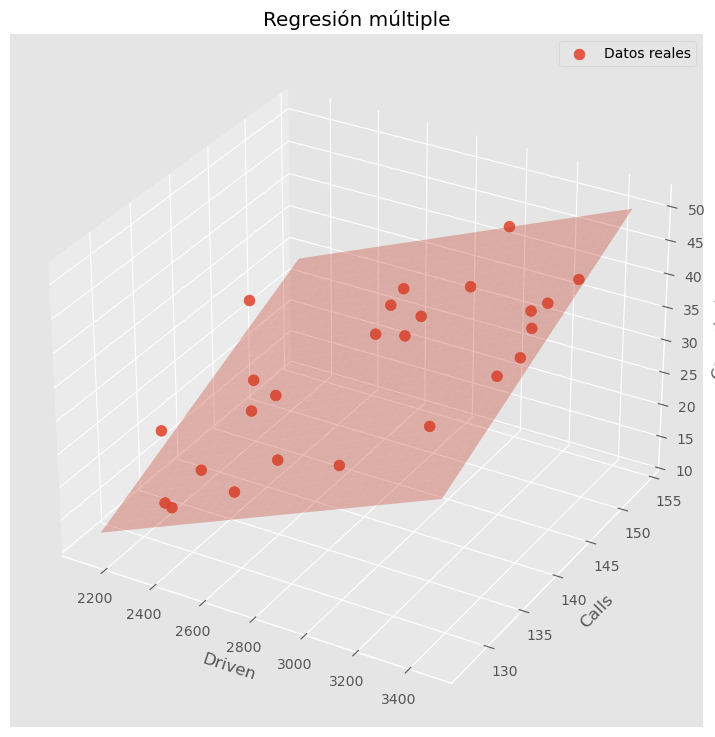

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

X2 = X[["Driven", "Calls"]].copy()
y_true = y["Commissions"].values.ravel()
y_hat = y_pred.ravel()

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(
    X2["Driven"].values, X2["Calls"].values, y_true,
    marker="o", s=60, alpha=0.9, label="Datos reales"
)

# Malla para el plano
driven_min, driven_max = X2["Driven"].min(), X2["Driven"].max()
calls_min, calls_max = X2["Calls"].min(), X2["Calls"].max()

driven_grid = np.linspace(driven_min, driven_max, 30)
calls_grid  = np.linspace(calls_min, calls_max, 30)
DRIVEN, CALLS = np.meshgrid(driven_grid, calls_grid)

grid_points = np.column_stack([DRIVEN.ravel(), CALLS.ravel()])
Z = model.predict(grid_points).reshape(DRIVEN.shape)

# Plano
ax.plot_surface(DRIVEN, CALLS, Z, alpha=0.35)

ax.set_xlabel("Driven")
ax.set_ylabel("Calls")
ax.set_zlabel("Commissions")
ax.set_title("Regresión múltiple")
ax.legend()
plt.show()


# Conclusión

Los resultados indican que los agentes que realizan más llamadas de ventas y recorren más millas tienden a obtener mayores comisiones. Ambos coeficientes son positivos, lo que muestra que tanto el esfuerzo en contacto con clientes como el desplazamiento contribuyen al aumento de las comisiones, y el valor de R a la 2 = 0.835, confirma que el modelo explica una proporción muy alta de la variación en los ingresos por comisiones. 